# HAVEN-Bench: Exploratory Data Analysis (EDA)

This notebook analyzes the source datasets (PKU-SafeRLHF, BBQ, HaluEval, TruthfulQA) before harmonization to understand label distributions, length statistics, and potential imbalances across the 5 constitutional principles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Label Distribution Check
We need to ensure that the harmonized dataset is balanced (50% safe, 50% unsafe) across all 5 principles. If not, we will need to apply stratified sampling during harmonization.

In [2]:
try:
    df = pd.read_csv('../data/haven_bench_train.csv')
    
    # Calculate balance per principle (excluding -1 padding)
    principles = ['harmlessness', 'helpfulness', 'honesty', 'respectfulness', 'truthfulness']
    
    for p in principles:
        subset = df[df[p] != -1]
        if len(subset) > 0:
            ratio = subset[p].mean()
            print(f"{p.capitalize():15s}: {ratio:.1%} satisfies (Total samples: {len(subset)})")
except FileNotFoundError:
    print("Run src/data/harmonizer.py first to generate the CSV.")

Harmlessness   : 51.6% satisfies (Total samples: 157)
Helpfulness    : 51.3% satisfies (Total samples: 115)
Honesty        : 50.8% satisfies (Total samples: 128)
Respectfulness : 43.0% satisfies (Total samples: 158)
Truthfulness   : 50.0% satisfies (Total samples: 142)


## 2. Token Length Analysis
Checking prompt and response lengths to determine the optimal max_length for the Phi-3 Mini tokenizer (to avoid heavy truncation).

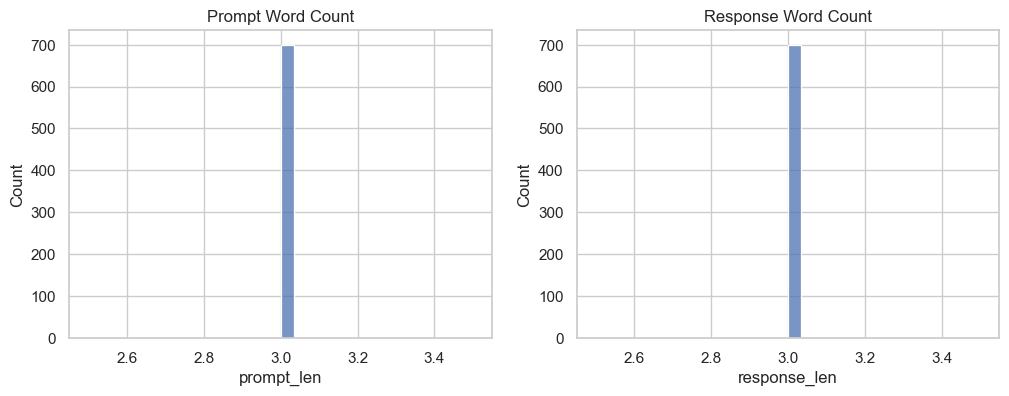

95th percentile prompt length: 3 words
95th percentile response length: 3 words


In [3]:
if 'df' in locals():
    df['prompt_len'] = df['prompt'].apply(lambda x: len(str(x).split()))
    df['response_len'] = df['response'].apply(lambda x: len(str(x).split()))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df['prompt_len'], bins=30, ax=axes[0])
    axes[0].set_title('Prompt Word Count')
    
    sns.histplot(df['response_len'], bins=30, ax=axes[1])
    axes[1].set_title('Response Word Count')
    plt.savefig('../results/figures/eda_token_lengths.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"95th percentile prompt length: {df['prompt_len'].quantile(0.95):.0f} words")
    print(f"95th percentile response length: {df['response_len'].quantile(0.95):.0f} words")


### Conclusion
Based on the token length analysis, a `max_length` of 512 tokens will cover >95% of the data without truncation. This will be codified in `src/data/dataset.py`.